# Аутентификация и авторизация

## Цели занятия

1. Разобраться с ключевыми терминами и понятиями управления доступом
2. Рассмотреть основные схемы аутентификации и способы разграничения прав пользователей
3. Изучить стандартные подходы и готовые инструменты/фреймворки для управления доступом

## Содержание

- Ключевые термины и понятия в механизмах управления доступом
  - Идентификация, аутентификация, авторизация
  - Аутентификация и авторизация в Web сервисах
  - Пример реализации двухфакторной аутентификация с помощью TOTP
- Распространенные способы разграничения прав пользователей
  - Access Control List (ACL)
  - Role-Based Access Control (RBAC)
  - Attribute-Based Access Control (ABAC)
- Протокол OAuth 2.0
- Управление доступом с помощью Keycloak

## Ключевые термины и понятия в механизмах управления доступом

### Идентификация, аутентификация, авторизация

__Идентификация (Identification)__ - это процесс предъявления _идентификатора_

- Чтобы система могла отличить пользователя по его _идентификатору_ от любого другого пользователя
- Идентификация не требует знания секретных данных. Ваш логин, номер телефона, открытый ключ - это не секретная информация, это публичный идентификатор, который мы можете предоставить по запросу любому
- Примеры:
    1. Вы заходите в учетную запись на компьютере и вводите логин
    1. Вы заходите на сайт и вводите номер телефона
    1. Сервер передает x.509 сертификат с открытым ключом

__Аутентификация (Authentication)__ - это процесс проверки и подтверждения заявленной _идентичности_

- Чтобы система убедилась в том, что вы точно являетесь тем, кем представились ранее, смогла подтвердить вашу _идентичность_
- Аутентификация требует знания секретных данных. Ваш пароль, одноразовый код, закрытый ключ - это секретная информация, факт владения этой информацией доказывает, что вы именно тот, за кого себя выдаете
- Примеры:
    1. Вы заходите в учетную запись на компьютере и после ввода логина вводите пароль
    1. Вы заходите на сайт и после ввода номер телефона вы вводите код, отправленный вам по смс
    1. Сервер расшифровывает `pre-master secret` полученный от клиента своим закрытым ключом

__Авторизация (Authorization)__ - это процесс определения ваших прав и возможностей

- После того как система узнала, кто вы (идентификация) и подтвердила это (аутентификация), она проверяет ваши права, что вы можете делать в этой системе
- Примеры:
    1. Можете ли вы создавать новых пользователей
    1. Можете ли вы скачивать отчеты бухгалтерии

Взаимосвязь этих терминов:

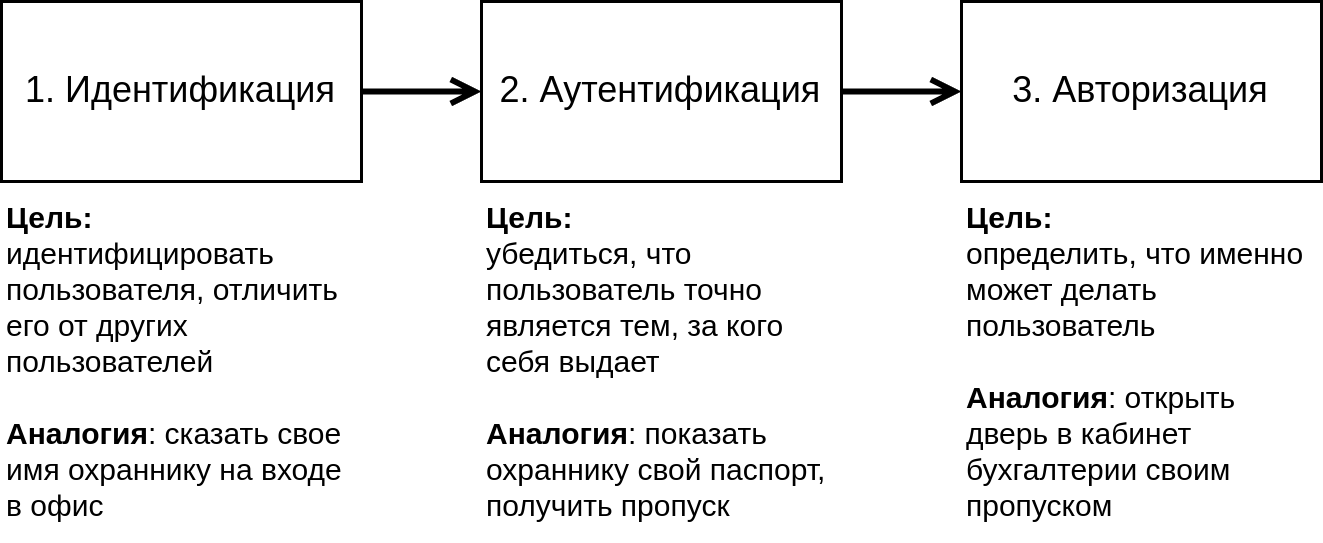

[Open Worldwide Application Security Project (OWASP) Authentication Cheat Sheet](https://github.com/OWASP/CheatSheetSeries/blob/master/cheatsheets/Authentication_Cheat_Sheet.md)

### Аутентификация и авторизация в Web сервисах

__Проблема__: Повторная аутентификация в КАЖДОМ клиент-серверном запросе для конкретного сервера

Взаимодействие клиента и сервера состоит из множества запросов. Если сервер будет выполнять полную аутентификацию (проверять логин и пароль, сертификат или другой сложный механизм) для каждого запроса, это приведет к двум ключевым проблемам:

1. Угроза безопасности: Секретные данные (пароли, приватные ключи) будут передаваться по сети многократно, увеличивая риск их перехвата
2. Низкая производительность и масштабируемость: Сложные криптографические операции (например, проверка пароля или подписи) создают высокую вычислительную нагрузку на сервер, замедляя обработку запросов.

__Решение__: Использовать принцип "одна полноценная аутентификация - много легких проверок":

1. _Создание артефакта_: При первой успешной аутентификации сервер создает для клиента уникальный артефакт - идентификатор сессии (Session ID) или самодостаточный токен (чаще всего это JWT токен)
1. _Использование артефакта_: Сервер передает артефакт клиенту. Клиент сохраняет его и прикладывает к каждому последующему запросу:
    - Session ID передается через HTTP куки
    - Токен через Authorization хедер
1. _Проверка артефакта_: Сервер, получив артефакт, не выполняет сложную аутентификацию заново. Вместо этого он:
    - Проверяет подлинность артефакта (например, цифровую подпись JWT или ищет Session ID в своем хранилище)
    - Извлекает из него контекст (идентификатор пользователя, роли), который был сохранен при создании

Такой подход значительно безопаснее (секретные данные передаются один раз) и эффективнее (сервер выполняет легкую проверку подписи или поиск по ключу вместо тяжелых криптоопераций)

Это основа для работы современных __stateful__ (сессии) и __stateless__ (токены) механизмов управления доступом

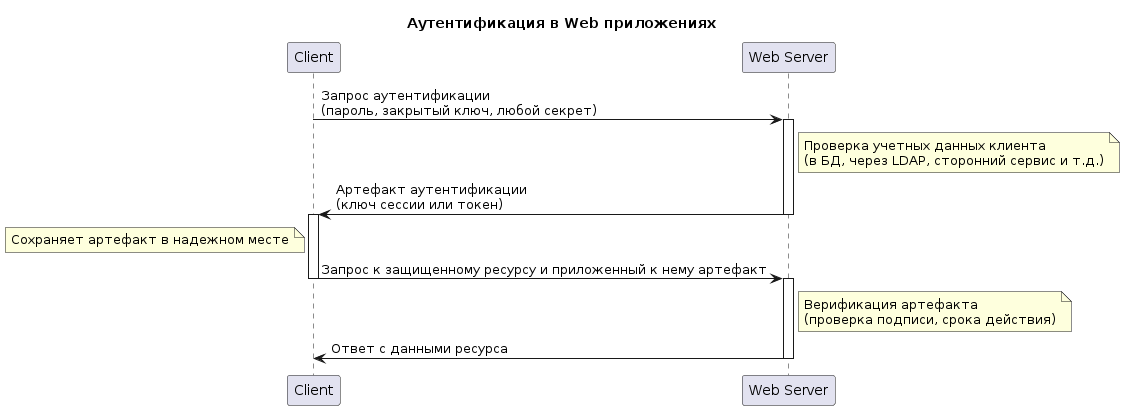

### Пример реализации двухфакторной аутентификация с помощью TOTP

In [5]:
# Файл assets/code/01_totp_example.py

## Распространенные способы разграничения прав пользователей

Разграничение прав доступа (Access Control) - это совокупность политик, процедур и механизмов, которые определяют, кто (_Subject_), с какимм ресурсами (_Object_) и какие действия (Action) может выполнять

Ключевые компоненты:

- Субъект (Subject): Пользователь, программа, процесс
- Объект (Object): Файл, база данных, строка в таблице, API-эндпоинт, принтер
- Действие (Action): Чтение, запись, выполнение, удаление, изменение

### Access Control List (ACL)

Список контроля доступа (Access Control List, ACL) - самый простой и наглядный подход

Как работает: У каждого объекта (Object) есть свой список, в котором указано, каким субъектам (Subject) и какие операции (Action) над этим объектом разрешены

Классический пример ACL: права доступа к файлам и каталогам UNIX

```txt
-rwxrw-r--  1 kirill kirill        20 дек 12 11:20  i3-workspace-1.json
-rwxrw-r--  1 kirill kirill      2938 дек 12 11:20  i3-workspace-2.json
-rwxrw-r--  1 kirill kirill      1850 дек 12 11:20  i3-workspace-3.json
```

Для каждого файла или каталога хранится список, в нем указано что могут делать определенные субъекты:

- Владелец - первый октет `rwx`
  - `r` - читать содержимое
  - `w` - писать содержимое
  - `x` - исполнять
- Группа владельца - второй октет `rw-`
  - `r` - читать содержимое
  - `w` - писать содержимое
  - `-` - НЕ могут исполнять
- Все остальные - третий октет `r--`
  - `r` - читать содержимое
  - `-` - НЕ могут писать содержимое
  - `-` - НЕ могут исполнять

__Плюсы__:

- Проще реализовать
- Легко посмотреть на объект и увидеть все его права 

__Минусы__:

- Проблема масштабирования: Управлять правами тысячи пользователей на тысяче файлов становится очень трудно. Нужно менять ACL на каждом объекте
- Неудобство для управления пользователями: Чтобы отозвать права у одного человека, нужно пройтись по всем объектам и удалить его из их ACL

__Где используется__: Файловые системы (NTFS, ext4), сетевые устройства (фильтрация пакетов, фаерволы)

Иллюстрация принципа на Python:

In [8]:
# Файл assets/code/02_acl_example.py

### Role-Based Access Control (RBAC)

Ролевое управление доступом (Role-Based Access Control, RBAC) - это более абстрактная и удобная для администрирования модель, _сфокусированная на субъектах, а не объектах_

Как работает: Права назначаются не пользователям (User) напрямую, а ролям (Role). Пользователям присваиваются одна или несколько ролей. Роль - это набор разрешений (Permission), необходимых для выполнения определенной работы

Ключевые понятия:

- Пользователь (User): получатель роли
- Роль (Role): Менеджер, Аналитик, Администратор
- Разрешение (Permission): Конкретное право на действие с объектом (например, document:edit)

__Плюсы__:
- Удобство администрирования: Чтобы изменить права для всех менеджеров, достаточно поменять разрешения у роли Менеджер
- Масштабируемость: Легко добавлять новых пользователей
- Соответствие структуре организации: Роли часто отражают должности

__Минусы__:
- Сложность поддержки: В сложных системах может появиться тысячи очень специфических ролей.
- Слабая контекстность: Стандартный RBAC не учитывает условия (время, местоположение, состояние объекта). Например, Менеджер может редактировать документ всегда, а не только в рабочее время или только свои документы (это уже требует ABAC).

__Где используется__: Подавляющее большинство корпоративных приложений (ERP, CRM, CMS), Web приложения

Чаще всего RBAC отделяют от бизнес логики приложения и выносят в отдельный сервис или фреймворк:

- [Keycloak: Authorization Services Guide](https://www.keycloak.org/docs/latest/authorization_services/index.html)
- [Casbin: open-source authorization framework](https://casbin.org/)

Иллюстрация принципа на Python:

In [9]:
# Файл assets/code/03_rbac_example.py

### Attribute-Based Access Control (ABAC)

Управление доступом на основе атрибутов (Attribute-Based Access Control, ABAC) - самая гибкая и мощная модель, которая принимает решение на основе множества атрибутов и условий

Как работает: Доступ разрешается или запрещается путем оценки __правил (политик)__ против __атрибутов__:
- _Атрибуты субъекта_: Должность, отдел, стаж, уровень безопасности
- _Атрибуты объекта_: Категория документа, метка конфиденциальности, кто владелец, дата создания
- _Атрибуты среды (контекста)_: Время суток, день недели, местоположение, уровень угрозы
- _Атрибут действия_: Что именно пытаются сделать

__Плюсы__:
- Высокая гранулярность: Можно описать очень тонкие политики
- Динамичность: Решение принимается в момент запроса с учетом текущего контекста

__Минусы__:
- Сложность: Проектирование, реализация и тестирование политик требуют значительных усилий
- Производительность: Оценка множества атрибутов и правил для каждого запроса может быть ресурсоемкой
- Риск ошибок в политиках: Сложные правила могут конфликтовать

__Где используется__: Государственные и оборонные системы, финансовые учреждения, облачные платформы (AWS IAM, Azure Policy используют концепции ABAC)

Чаще всего ABAC тоже отделяют от бизнес логики приложения и выносят в отдельный сервис или фреймворк:

- [Keycloak: Authorization Services Guide](https://www.keycloak.org/docs/latest/authorization_services/index.html)
- [Casbin: open-source authorization framework](https://casbin.org/)
- [SpiceDB](https://authzed.com/docs/spicedb/getting-started/discovering-spicedb)


### Итоговое сравнение

| Модель | Фокус | Гибкость | Сложность администрирования | Контекст |
| :--- | :--- | :--- | :--- | :--- |
| __ACL__ | __Объект__ ("Кто имеет доступ к этому?") | Низкая | Высокая (для многих пользователей) | Нет |
| __RBAC__ | __Субъект / Роль__ ("Что может этот тип пользователя?") | Средняя | __Низкая__ (основное преимущество) | Очень ограниченный |
| __ABAC__ | __Политика / Атрибуты__ ("Разрешить ли доступ в *этих* условиях?") | __Очень высокая__ | Средняя/Высокая (управление политиками) | __Полноценный__ |

Модели доступа развивались от простой __ACL__ к более управляемой __RBAC__ и далее к максимально гибкому контекстно-зависимому __ABAC__

## Протокол OAuth 2.0

Какую проблему решает OAuth 2.0:

- Я разрабатываю приложение `CalendarPlanner`, в нем можно планировать и отслеживать события в календаре
- Я не хочу придумывать свою бизнес логику календаря, я хочу чтобы пользователь вносил события в свой Google календарь, но делал это через мое приложение `CalendarPlanner`
- Значит мой `CalendarPlanner` должен каким-то образом иметь права на управление Google календарем пользователя

Как этого можно добиться?

- Пусть пользователь вводит в приложение `CalendarPlanner` логин и пароль от своего Google аккаунта, затем приложение `CalendarPlanner` само будет авторизоваться на сервисах Google и выдавать себя за пользователя, тогда оно сможет управлять календарем

Почему это плохое решение?

- Ни один адекватный пользователь не будет вводить логин и пароль от своего Google аккаунта в другом приложении

Как можно улучшить это решение?

- Использовать OAuth 2.0
- Благодаря OAuth подходам `CalendarPlanner` вообще не нужно знать логин и пароль от Google аккаунта пользователя, ему достаточно получить от пользователя разрешение на управление его Google календарем
- Если пользователь дал разрешение, `CalendarPlanner` получает от Google специальный __Access Token__ и использует этот токен чтобы работать с Google календарем пользователя

Ключевые взаимодействующие компоненты OAuth 2.0:
- __Resource Owner__: Тот, кто владеет данными и может разрешить доступ к ним
    - В нашем примере это пользователь, а его данные это Google календарь
- __Client__: Приложение, которое хочет получить доступ к данным пользователя. Это не пользователь!
    - В нашем примере это приложение `CalendarPlanner`
- __Resource Server__: Хранит защищенные данные пользователя. Принимает запросы с Access Token и выдает данные, если токен валиден
    - В нашем примере это API сервер Google календаря
- __Authorization Server__: Выдает Access и Refresh токены клиентам после успешной аутентификации пользователя и получения его согласия. Часто это тот же сервер, что и _Resource Server_
    - В нашем примере это API сервер Google авторизации

Ключевые артефакты взаимодействия OAuth 2.0:
- __Authorization Grant__: Доказательство, что пользователь дал клиенту разрешение. Этот Grant клиент должен обменять на Access и Refresh токены у _Authorization Server_
- __Access Token__: Ключ, который клиент предъявляет _Resource Server_ как доказательство того, что пользователь разрешил модифицировать его данные. Для безопасности этот токен живет не долго, чаще всего 3600 секунд
- __Refresh Token__: Долгоживущий токен, который клиент может использовать, чтобы получить новый Access Token, когда старый истек. Хранится в максимальной безопасности

Есть различные способы получить __Access Token__ самый популярный и безопасный для Web приложений - __Authorization Code Flow__: 
- Пользователя перенаправляют на страницу согласия провайдера
- Провайдер перенаправляет обратно с кодом (authorization_code)
- Клиент на бэкенде обменивает код на токен
- Клиент использует токен для получения ресурсов

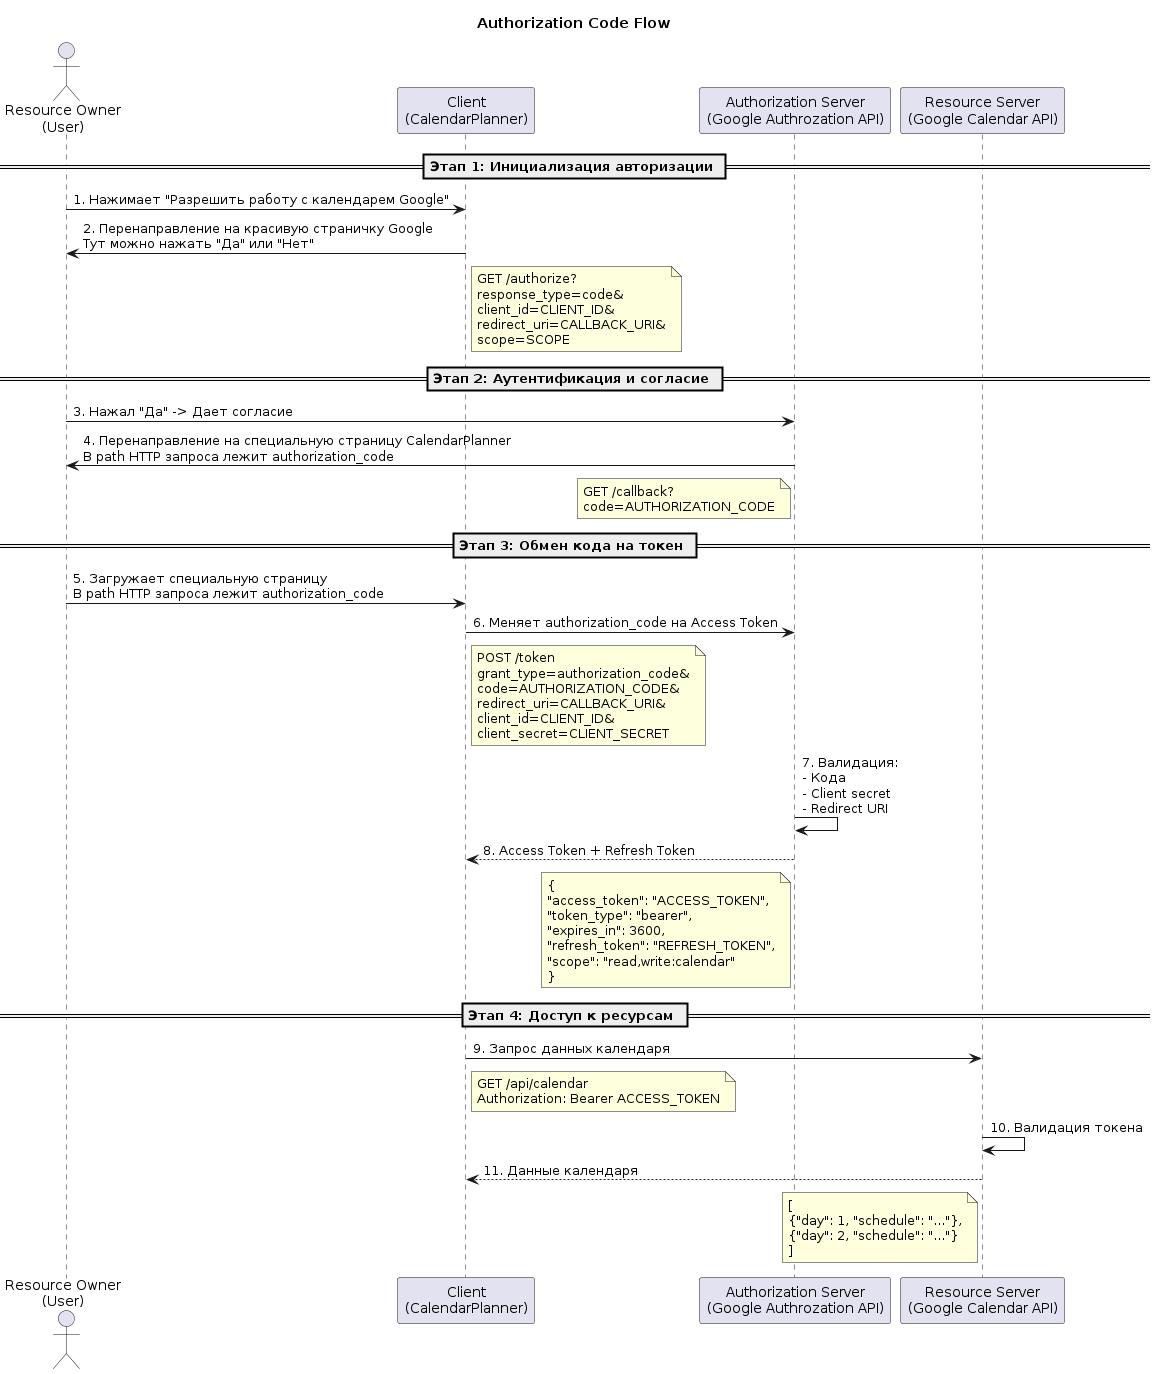

[RFC 6749: The OAuth 2.0 Authorization Framework](https://datatracker.ietf.org/doc/html/rfc6749)

## Управление доступом спомощью Keycloak

Keycloak - это полноценное open-source решение для Identity and Access Management (IAM). Это комплексное решение с открытым исходным кодом, которое охватывает все ключевые аспекты IAM

Ключевые аспекты:

- Аутентификация: Поддерживает множество протоколов, в том числе _OpenID Connect_, _SAML 2.0_
- Разграничение прав пользователей: Предоставляет детализированную авторизацию на основе ролей (RBAC) и атрибутов (ABAC) через политики и разрешения
- Управление пользователями: Централизованное хранилище пользователей, включая регистрацию, профили, группы, управление паролями
- Single Sign-On - Keycloak хранит сессии залогиненных пользователей и позволяет сторонним приложения связанным с Keyclock использовать эти сесии для аутетификации пользователей с помощью _OAuth 2.0_ (в этом случае Keycloak выступает в роли Authorization Server, а приложение в роли Client)
- Вход через социальные сети: благодаря поддержке _OAuth 2.0_ можно настроить интеграцию и вход через популярные социальные сети (Google, Github, Gitalb, Twitter, etc)
- Встроенная поддержка Multi Factor Authentication

В Keycloak есть очень много разных сущностей, но мы рассмотрим ключевые, без которых не получится интегрировать наше приложение с Keycloak:

- __Realm__ - изолированное пространство для группы приложений и пользователей
  - Все последующие сущности настраиваются в рамках реалма
  - Приложения из разных реалмов не знают друг о друге
  - Часто реалмы мапятся на какие-то организационные сущности, например:
    - 1 реалм на всю организацию/компанию (если она небольшая)
    - Отдельный реалм на каждое подразделение в компании
    - Отдельный реалм для dev/prod/staging окружения крупного продукта
- __Client__ - приложение или сервис, которое будет использовать Keycloak для аутентификации
  - `client_id` - идентификатор клиента
  - `client_secret` - секрет клиента, как API ключ или пароль
  - `redirect_uris` - список URL на которые Keycloak перенаправит пользователя после логина
- __User__ - конечные пользователи приложения
  - У пользователей есть username, email, password
  - Пользователям можно назначать роли
  - У пользователей могут быть произвольные полезные атрибуты
- __Role__ - набор прав/привилегий для пользователей
  - Роли бывают 2 видов:
    - Realm roles - действуют на уровне всего реалма
    - Client roles - действуют на уровне конкретного клиента


Иллюстрация приложения на Python:

In [1]:
# Файл assets/code/04_keycloak_example.py

## Домашнее задание: Аутентификация и авторизация

Необходимо добавить аутентификацию по JWT токену и минимальную RBAC-авторизацию в сервис инференса (FastAPI) из предыдущего задания

Необходимо добавить регистрацию пользователей, выполнить требования по формату JWT токена, добавить авторизацию и защищенные эндпоинты, добавить возможность настройки параметров безопасности через переменные окружения

## Итоги

1. Разобрались с ключевыми терминами и понятиями управления доступом
2. Рассмотрели основные схемы аутентификации и способы разграничения прав пользователей
3. Изучили стандартные подходы и готовые инструменты/фреймворки для управления доступом